In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels as sm
import seaborn as sns
import sklearn as sk
import warnings
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

## EDA Continued

In [2]:
url = 'https://raw.githubusercontent.com/aspenwang-vassar/CMPU-250-Project-Group-1/refs/heads/main/data/cleaned_data.csv'
df = pd.read_csv(url)
df_copy = df.copy()
df

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Hospital,Insurance Provider,Billing Amount,Admission Type,Discharge Date,Medication,Test Results,Race,Admission Length,Age Group
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Sons and Miller,Blue Cross,18856.281306,Urgent,2024-02-02,Paracetamol,Normal,White,2,21-40
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Kim Inc,Medicare,33643.327287,Emergency,2019-08-26,Ibuprofen,Inconclusive,Hispanic,6,40-65
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Cook PLC,Aetna,27955.096079,Emergency,2022-10-07,Aspirin,Normal,White,15,65+
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,"Hernandez Rogers and Vang,",Medicare,37909.782410,Elective,2020-12-18,Ibuprofen,Abnormal,White,30,21-40
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,White-White,Aetna,14238.317814,Urgent,2022-10-09,Penicillin,Abnormal,White,20,40-65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,Elizabeth Jackson,42,Female,O+,Asthma,2020-08-16,Jones-Thompson,Blue Cross,2650.714952,Elective,2020-09-15,Penicillin,Abnormal,African American,30,40-65
55496,Kyle Perez,61,Female,AB-,Obesity,2020-01-23,Tucker-Moyer,Cigna,31457.797307,Elective,2020-02-01,Aspirin,Normal,White,9,40-65
55497,Heather Wang,38,Female,B+,Hypertension,2020-07-13,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,Urgent,2020-08-10,Ibuprofen,Abnormal,Hispanic,28,21-40
55498,Jennifer Jones,43,Male,O-,Arthritis,2019-05-25,"Jackson Todd and Castro,",Medicare,32451.092358,Elective,2019-05-31,Ibuprofen,Abnormal,Hispanic,6,40-65


# Adding Correlation between our predictors and outcome of Billing Amount
Given the synthetic nature of our data we need to inject correlation based of real world statistics. This will increase the predictive accuracy of our algorithms



In [3]:
#Resetting the Billing Amount(outcome) Category to 0 and re-calculating based on real-world statistics

df['Billing Amount'] = 0

In [4]:
#Length of Admission: Increase Billing Amount by $3,025 to account for the daily cost of a hospital stay
df['Billing Amount'] = df['Billing Amount'] + (3025 * df['Admission Length'])

In [5]:
#Medical Condition: Adjust the Billing Amount based on the daily costs of each condition being treated

#Create the dictionary of daily costs
daily_costs = {
    'Diabetes': 54.00,
    'Asthma': 9.00,
    'Hypertension': 7.56,
    'Obesity': 6.87,
    'Arthritis': 14.00,
    'Cancer': 3400.00
}
# get the daily cost of each treatment
cost = df['Medical Condition'].map(daily_costs).fillna(0)

#Calculate adjustment amount and add it to the billing amount
df['Billing Amount'] = df['Billing Amount'] + (cost * df['Admission Length'])

df[['Medical Condition', 'Admission Length', 'Billing Amount']].head()

,Medical Condition,Admission Length,Billing Amount
0,Cancer,2,12850.00
1,Obesity,6,18191.22
2,Obesity,15,45478.05
3,Diabetes,30,92370.00
4,Cancer,20,128500.00


In [6]:
#Age Group: Increment billing amount based on age
conditions = [
    df['Age'] < 21,
    (df['Age'] >= 21) & (df['Age'] <= 40),
    (df['Age'] > 40) & (df['Age'] <= 65),
    df['Age'] > 65
]
choices = [2000, 3000, 6500, 11000]
df['Billing Amount'] = df['Billing Amount'] + np.select(conditions, choices, default=0)
df

df['Billing Amount']

,Billing Amount
0,15850.00
1,24691.22
2,56478.05
3,95370.00
4,135000.00
...,...
55495,97520.00
55496,33786.83
55497,87911.68
55498,24734.00


In [7]:
#Admission Type: Adding 2K for Admission types of Emergency
df.loc[df['Admission Type'] == 'Emergency', 'Billing Amount'] += 2000


df['Billing Amount']

,Billing Amount
0,15850.00
1,26691.22
2,58478.05
3,95370.00
4,135000.00
...,...
55495,97520.00
55496,33786.83
55497,87911.68
55498,24734.00


In [8]:
#Race: Multipliers for different Race's average billing amount
df.loc[df['Race'] == 'Hispanic', 'Billing Amount'] *= 1.28
df.loc[df['Race'] == 'African American', 'Billing Amount'] *= 1.57
df.loc[df['Race'] == 'White', 'Billing Amount'] *= 1.74
df.loc[df['Race'] == 'Multiracial', 'Billing Amount'] *= 1.98

df[['Race', 'Billing Amount']].head()

,Race,Billing Amount
0,White,27579.0000
1,Hispanic,34164.7616
2,White,101751.8070
3,White,165943.8000
4,White,234900.0000


# Historical Bias
To inject historical bias we will subtract 1800 from all African American Billing Amounts. This represents the historical trend that African American patients had less resources to pursue proper care compared to White patient's.

In [9]:
hist_df = df
hist_df.loc[df['Race'] == 'African American','Billing Amount'] -= 1800

hist_df[hist_df['Race'] == 'African American']['Billing Amount']
df[df['Race'] == 'African American']['Billing Amount']

,Billing Amount
11,112415.7416
15,56005.3590
23,56038.8000
34,122066.7200
36,27080.1500
...,...
55469,21994.9200
55470,44888.6600
55476,53650.3590
55479,250499.0000


https://github.com/aspenwang-vassar/CMPU-250-Project-Group-1/blob/main/data/clean_data.csv## Datasets

# Representational Bias Analysis
We will create biased dataset's representing different kinds of representation bias that can occur during data collection(Race,Gender,Age)

#1. Race/Ethinicity

Load Data

In [10]:
warnings.filterwarnings('ignore') # surpress warnings

url = 'https://raw.githubusercontent.com/aspenwang-vassar/CMPU-250-Project-Group-1/refs/heads/main/data/full_data.csv'
df = pd.read_csv(url)
df_copy = df.copy()
df

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Hospital,Insurance Provider,Billing Amount,Admission Type,Discharge Date,Medication,Test Results,Race,Admission Length,Age Group
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Sons and Miller,Blue Cross,30859.992947,Urgent,2024-02-02,Paracetamol,Normal,White,2,21-40
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Kim Inc,Medicare,38471.107493,Emergency,2019-08-26,Ibuprofen,Inconclusive,Hispanic,6,40-65
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Cook PLC,Aetna,106615.993718,Emergency,2022-10-07,Aspirin,Normal,White,15,65+
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,"Hernandez Rogers and Vang,",Medicare,172540.102139,Elective,2020-12-18,Ibuprofen,Abnormal,White,30,21-40
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,White-White,Aetna,237377.467300,Urgent,2022-10-09,Penicillin,Abnormal,White,20,40-65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,Elizabeth Jackson,42,Female,O+,Asthma,2020-08-16,Jones-Thompson,Blue Cross,153522.562248,Elective,2020-09-15,Penicillin,Abnormal,African American,30,40-65
55496,Kyle Perez,61,Female,AB-,Obesity,2020-01-23,Tucker-Moyer,Cigna,64262.740931,Elective,2020-02-01,Aspirin,Normal,White,9,40-65
55497,Heather Wang,38,Female,B+,Hypertension,2020-07-13,"and Mahoney Johnson Vasquez,",UnitedHealthcare,116062.408284,Urgent,2020-08-10,Ibuprofen,Abnormal,Hispanic,28,21-40
55498,Jennifer Jones,43,Male,O-,Arthritis,2019-05-25,"Jackson Todd and Castro,",Medicare,35813.259822,Elective,2019-05-31,Ibuprofen,Abnormal,Hispanic,6,40-65


Create Biased Datasets

In [11]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# --- 1. Helper Function ---
def create_biased_dataset(df, target_percentage, column_name, majority_group):
    """
    Creates a biased dataset by randomly changing rows from 'Minority' groups
    to the 'Majority' group to achieve the target percentage.
    """
    biased_df = df.copy()
    total_rows = len(biased_df)
    target_count = int(total_rows * target_percentage)

    current_count = len(biased_df[biased_df[column_name] == majority_group])
    rows_to_change = target_count - current_count

    if rows_to_change <= 0:
        return biased_df

    minority_indices = biased_df[biased_df[column_name] != majority_group].index

    if len(minority_indices) < rows_to_change:
        print(f"Warning: Not enough rows to flip for {column_name} {target_percentage}")
        return biased_df

    indices_to_flip = np.random.choice(minority_indices, size=rows_to_change, replace=False)
    biased_df.loc[indices_to_flip, column_name] = majority_group
    return biased_df



In [12]:
# --- 2. Configuration ---
original_df = df.copy()

# Define the baseline (Unbiased)
datasets_to_generate = {
    'unbiased': original_df
}

# Define Bias Configurations
bias_targets = [
    {"col": "Race",      "majority": "White"},
    {"col": "Gender",    "majority": "Male"},
    {"col": "Age Group", "majority": "21-40"}
]
percentages = [0.70, 0.80, 0.90]

In [13]:
# --- 3. Generate ALL Biased Dataframes First ---
print("--- Generating Biased Populations ---")

for target in bias_targets:
    for pct in percentages:
        key_name = f"{target['col']}_{int(pct*100)}"

        # Apply bias to the FULL dataframe
        biased_data = create_biased_dataset(
            original_df,
            target_percentage=pct,
            column_name=target['col'],
            majority_group=target['majority']
        )

        datasets_to_generate[key_name] = biased_data
        print(f"Generated full dataset for {key_name}")


--- Generating Biased Populations ---
Generated full dataset for Race_70
Generated full dataset for Race_80
Generated full dataset for Race_90
Generated full dataset for Gender_70
Generated full dataset for Gender_80
Generated full dataset for Gender_90
Generated full dataset for Age Group_70
Generated full dataset for Age Group_80
Generated full dataset for Age Group_90


## Creating Train-Test Split for Racial Biased Dataset

In [14]:
# --- Train-Test Split ---
# We split all datasets to generate training data for every bias configuration.
# However, we ONLY retain the 'unbiased' test set

training_sets = {}
test_sets = {}

print("\n--- Splitting into Train/Test Sets ---")

for key, dataset in datasets_to_generate.items():

    # Perform the split
    X_train, X_test = train_test_split(dataset, test_size=0.2, random_state=42)

    # Always store the Training Set
    training_sets[key] = X_train

    # Conditionally store the Test Set
    if key == 'unbiased':
        test_sets[key] = X_test
        print(f"[{key}] Train: {len(X_train)} | Test: {len(X_test)}")
    else:
        # We discard the test portion of biased datasets
        print(f"[{key}] Train: {len(X_train)} | Test: Discarded")

print(f"\nPipeline Complete.")
print(f"Total Training Sets: {len(training_sets)}")
print(f"Total Test Sets: {len(test_sets)}")
print(f"Test Set Keys: {list(test_sets.keys())}")


--- Splitting into Train/Test Sets ---
[unbiased] Train: 44400 | Test: 11100
[Race_70] Train: 44400 | Test: Discarded
[Race_80] Train: 44400 | Test: Discarded
[Race_90] Train: 44400 | Test: Discarded
[Gender_70] Train: 44400 | Test: Discarded
[Gender_80] Train: 44400 | Test: Discarded
[Gender_90] Train: 44400 | Test: Discarded
[Age Group_70] Train: 44400 | Test: Discarded
[Age Group_80] Train: 44400 | Test: Discarded
[Age Group_90] Train: 44400 | Test: Discarded

Pipeline Complete.
Total Training Sets: 10
Total Test Sets: 1
Test Set Keys: ['unbiased']


## Feature Selections and Pipelines

In [15]:
# Feature Selection
features = [
    'Age',
    'Admission Length',
    'Race',
    'Gender',
    'Blood Type',
    'Medical Condition',
    'Insurance Provider',
    'Admission Type',
    'Medication',
    'Test Results',
    'Age Group']
target = 'Billing Amount'

# Create the preprocessing pipeline
numeric_features = ['Age', 'Admission Length']
categorical_features = [
    'Race',
    'Gender',
    'Blood Type',
    'Medical Condition',
    'Insurance Provider',
    'Admission Type',
    'Medication',
    'Test Results',
    'Age Group'
    ]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Define 3 models
models = {
    "LinearRegression": Pipeline(steps=[('preprocessor', preprocessor),
                                       ('regressor', LinearRegression())]),

    "PolynomialRegression_D2": Pipeline(steps=[('preprocessor', preprocessor),
                                               ('poly_features', PolynomialFeatures(degree=2, include_bias=False)),
                                               ('regressor', LinearRegression())]),

    "KNN_Regression_k15": Pipeline(steps=[('preprocessor', preprocessor),
                                         ('regressor', KNeighborsRegressor(n_neighbors=15))])
}


### Model training

In [16]:
from sklearn.base import clone
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# --- 1. Setup Data Containers ---

fitted_models = {}
aggregate_results = []

print(f"Starting training pipeline...")
print(f"Datasets available: {list(training_sets.keys())}")
print(f"Models defined: {list(models.keys())}")


# --- 2. Training Loop ---
print("\n--- Training Models ---")

for train_name, train_df in training_sets.items():

    # Prepare features and target
    X_train = train_df[features]
    y_train = train_df[target]

    for model_name, model_template in models.items():
        print(f"Training {model_name} on {train_name}...")

        # Create a fresh copy of the model
        model_instance = clone(model_template)

        # Fit the model
        model_instance.fit(X_train, y_train)

        # Store the fitted model for later analysis
        fitted_models[(train_name, model_name)] = model_instance

print(f"Successfully trained {len(fitted_models)} models.")




Starting training pipeline...
Datasets available: ['unbiased', 'Race_70', 'Race_80', 'Race_90', 'Gender_70', 'Gender_80', 'Gender_90', 'Age Group_70', 'Age Group_80', 'Age Group_90']
Models defined: ['LinearRegression', 'PolynomialRegression_D2', 'KNN_Regression_k15']

--- Training Models ---
Training LinearRegression on unbiased...
Training PolynomialRegression_D2 on unbiased...
Training KNN_Regression_k15 on unbiased...
Training LinearRegression on Race_70...
Training PolynomialRegression_D2 on Race_70...
Training KNN_Regression_k15 on Race_70...
Training LinearRegression on Race_80...
Training PolynomialRegression_D2 on Race_80...
Training KNN_Regression_k15 on Race_80...
Training LinearRegression on Race_90...
Training PolynomialRegression_D2 on Race_90...
Training KNN_Regression_k15 on Race_90...
Training LinearRegression on Gender_70...
Training PolynomialRegression_D2 on Gender_70...
Training KNN_Regression_k15 on Gender_70...
Training LinearRegression on Gender_80...
Training P

In [17]:
print("\n--- Evaluating Performance ---")

# Iterate through every trained model
for (train_name, model_name), model in fitted_models.items():

    # Test
    for test_name, test_df in test_sets.items():

        X_test = test_df[features]
        y_test = test_df[target]

        # Generate Predictions
        y_pred = model.predict(X_test)

        # Calculate Metrics
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        aggregate_results.append({
            "Train_Set": train_name,
            "Model": model_name,
            "Test_Set": test_name,
            "Mean Prediction": np.mean(y_pred),
            "RMSE": rmse,
            "R2": r2
        })



--- Evaluating Performance ---


Display Results

In [18]:
# --- View Results ---
results_df = pd.DataFrame(aggregate_results)

results_df = results_df.sort_values(by=['Model', 'Train_Set', 'RMSE'])

# Display results
print("\n Results:")
print(results_df.head(len(results_df)).to_string(index=False))



 Results:
   Train_Set                   Model Test_Set  Mean Prediction         RMSE       R2
Age Group_70      KNN_Regression_k15 unbiased    105987.855435 22024.693023 0.879131
Age Group_80      KNN_Regression_k15 unbiased    105830.883073 22212.491297 0.877061
Age Group_90      KNN_Regression_k15 unbiased    106178.272251 21996.605539 0.879439
   Gender_70      KNN_Regression_k15 unbiased    105819.031665 21464.790672 0.885198
   Gender_80      KNN_Regression_k15 unbiased    105773.650890 21590.770962 0.883846
   Gender_90      KNN_Regression_k15 unbiased    106112.325032 21502.311667 0.884796
     Race_70      KNN_Regression_k15 unbiased    104514.742626 22731.670241 0.871247
     Race_80      KNN_Regression_k15 unbiased    103896.470902 23827.168472 0.858538
     Race_90      KNN_Regression_k15 unbiased    103753.904102 25129.217028 0.842655
    unbiased      KNN_Regression_k15 unbiased    105722.821023 21438.318012 0.885481
Age Group_70        LinearRegression unbiased    10428

Visualization

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def visualize_aggregated_performance(results_df):
    # Data Prep
    plot_df = results_df.copy()

    # Parse dataset names to separate Type and Level
    def parse_bias(row):
        # FIX: Changed 'Original' to 'Unbiased' to match the plot order
        if row['Train_Set'] == 'unbiased': return pd.Series(['Baseline', 'Unbiased'])

        try:
            parts = row['Train_Set'].rsplit('_', 1)
            return pd.Series([parts[0], parts[1]])
        except:
            return pd.Series([row['Train_Set'], 'N/A'])

    plot_df[['Bias_Type', 'Bias_Level']] = plot_df.apply(parse_bias, axis=1)

    # 3. Define the order for the X-axis
    # This must match the values generated above exactly
    order = ['Unbiased', '70', '80', '90']

    # 4. Create the Plot

    # Filter only the bias types we care about for the facets
    bias_types = ['Race', 'Gender', 'Age Group']

    # Get the baseline rows (where Train_Set is 'unbiased')
    baseline_rows = plot_df[plot_df['Train_Set'] == 'unbiased']

    # Get the biased rows
    biased_rows = plot_df[plot_df['Bias_Type'].isin(bias_types)]

    combined_dfs = []
    for b_type in bias_types:
        # Get data for this specific bias type (e.g., just Race data)
        type_data = biased_rows[biased_rows['Bias_Type'] == b_type].copy()

        # Add the baseline data, but label it with the current Bias Type
        # so it appears in this specific facet panel
        baseline_copy = baseline_rows.copy()
        baseline_copy['Bias_Type'] = b_type

        combined_dfs.append(pd.concat([baseline_copy, type_data]))

    final_plot_df = pd.concat(combined_dfs)

    # 5. Plot
    g = sns.catplot(
        data=final_plot_df,
        x='Bias_Level',
        y='RMSE',
        hue='Model',
        col='Bias_Type',
        kind='point',
        height=5,
        aspect=1.0,
        order=order, # Now 'Unbiased' in order matches 'Unbiased' in data
        palette='viridis',
        markers=["o", "s", "D"],
        linestyles=["-", "--", ":"]
    )

    g.fig.suptitle('Impact of Training Bias on Model Performance (Test on Unbiased Data)', y=1.05)
    g.set_axis_labels('Bias Severity (% Majority)', 'RMSE (Error)')
    g.set_titles('Bias Type: {col_name}')

    plt.tight_layout()
    plt.show()

    # Alt Text
    print("**Figure: Aggregated Performance Degradation.**")
    print("This faceted point plot shows how the Root Mean Square Error (RMSE) changes for three models (Linear, Polynomial, KNN) as the training data becomes increasingly biased (from Original to 90% Majority).")
    print("Each panel represents a different demographic bias (Race, Gender, Age). Upward trends indicate that the model is losing accuracy as bias increases.")

Group Performance Analysis

In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# --- 1. Core Logic Functions ---

def calculate_rmse(df, target_col, pred_col):
    """Pure function to calculate RMSE."""
    return np.sqrt(mean_squared_error(df[target_col], df[pred_col]))

def analyze_bias(fitted_models, test_df, target_col, group_col, train_set_keys, feature_cols):
    """
    Universal function to analyze bias for a specific demographic group.

    Args:
        fitted_models: Dict of {(train_name, model_name): model_obj}
        test_df: The unbiased test dataframe to evaluate on
        target_col: Name of the target variable
        group_col: Name of the column to group by (e.g., 'Race')
        train_set_keys: List of training sets to include (e.g., ['unbiased', 'Race_90'])
        feature_cols: List of feature names used for prediction
    """
    results = []

    # Work on a copy to avoid SettingWithCopy warnings
    analysis_df = test_df.copy()
    unique_subgroups = analysis_df[group_col].dropna().unique()

    # Extract model names dynamically from the fitted_models keys
    model_names = set(k[1] for k in fitted_models.keys())

    for model_name in model_names:
        for train_name in train_set_keys:

            # Retrieve the specific model trained on this dataset
            try:
                model = fitted_models[(train_name, model_name)]
            except KeyError:
                continue # Skip if this specific combo doesn't exist

            # Generate Predictions on the Test Set
            pred_col = f'pred_{train_name}_{model_name}'
            analysis_df[pred_col] = model.predict(analysis_df[feature_cols])

            # Calculate RMSE for each demographic subgroup
            for subgroup in unique_subgroups:
                # Filter data for just this group (e.g., just 'Female')
                subset = analysis_df[analysis_df[group_col] == subgroup]

                if len(subset) > 0:
                    rmse = calculate_rmse(subset, target_col, pred_col)

                    results.append({
                        "Model": model_name,
                        "Train_Set": train_name,
                        "Subgroup": subgroup,
                        "RMSE": rmse,
                        "Category": group_col
                    })

    return pd.DataFrame(results)

def visualize_bias(df, category_name, sort_order=None):
    """
    Standardized visualization function to plot RMSE disparities.
    """
    if df.empty:
        print(f"No data to plot for {category_name}")
        return

    n_groups = df['Subgroup'].nunique()
    palette = sns.color_palette("colorblind", n_groups).as_hex()

    # Create Faceted Bar Chart
    g = sns.catplot(
        data=df,
        x='Train_Set',
        y='RMSE',
        hue='Subgroup',
        col='Model',
        kind='bar',
        height=5,
        aspect=1.0,
        order=sort_order,
        palette=palette,
        sharey=True,
        legend_out=True
    )

    g.fig.suptitle(f'{category_name} Bias Analysis (RMSE by Subgroup)', y=1.05)
    g.set_axis_labels('Training Dataset', 'RMSE (Error)')
    g.set_titles('{col_name}')
    g.set_xticklabels(rotation=45)



    plt.tight_layout()
    plt.show()

    # Alt Text / Insight Generator
    print(f"**Figure: {category_name} RMSE Disparity.**")
    print(f"The chart visualizes prediction error (RMSE) broken down by {category_name.lower()} subgroups.")
    print("Columns represent different algorithms. The X-axis shows the training data used, ranging from unbiased to highly biased.")
    print("Key Insight: Diverging bars (gaps between groups) indicate potential bias. If the gap grows as you move right (towards 90% bias), the model is sensitive to representation.")


--- Running Analysis: Race ---

Results:
                  Model Train_Set         Subgroup         RMSE Category
PolynomialRegression_D2  unbiased            White  2981.381267     Race
PolynomialRegression_D2  unbiased African American  2250.076776     Race
PolynomialRegression_D2  unbiased         Hispanic  3984.662601     Race
PolynomialRegression_D2  unbiased      Multiracial  5134.665080     Race
PolynomialRegression_D2  unbiased            Asian  6486.528817     Race
PolynomialRegression_D2   Race_70            White  5292.690797     Race
PolynomialRegression_D2   Race_70 African American  2443.310956     Race
PolynomialRegression_D2   Race_70         Hispanic  4099.955248     Race
PolynomialRegression_D2   Race_70      Multiracial  5289.783746     Race
PolynomialRegression_D2   Race_70            Asian  6540.510112     Race
PolynomialRegression_D2   Race_80            White  7830.875271     Race
PolynomialRegression_D2   Race_80 African American  2504.288049     Race
Polynomia

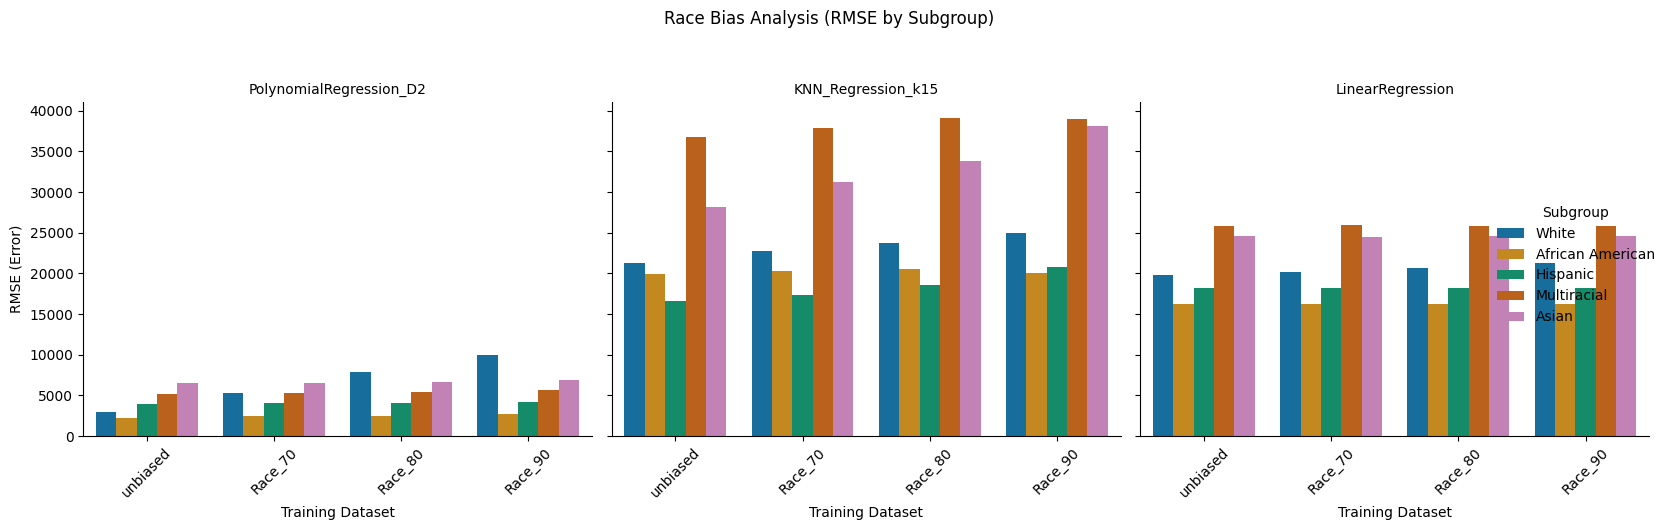

**Figure: Race RMSE Disparity.**
The chart visualizes prediction error (RMSE) broken down by race subgroups.
Columns represent different algorithms. The X-axis shows the training data used, ranging from unbiased to highly biased.
Key Insight: Diverging bars (gaps between groups) indicate potential bias. If the gap grows as you move right (towards 90% bias), the model is sensitive to representation.

--- Running Analysis: Gender ---

Results:
                  Model Train_Set Subgroup         RMSE Category
PolynomialRegression_D2  unbiased     Male  3437.227670   Gender
PolynomialRegression_D2  unbiased   Female  3559.787264   Gender
PolynomialRegression_D2 Gender_70     Male  3435.268010   Gender
PolynomialRegression_D2 Gender_70   Female  3559.496078   Gender
PolynomialRegression_D2 Gender_80     Male  3434.693106   Gender
PolynomialRegression_D2 Gender_80   Female  3561.485584   Gender
PolynomialRegression_D2 Gender_90     Male  3435.157331   Gender
PolynomialRegression_D2 Gender_90 

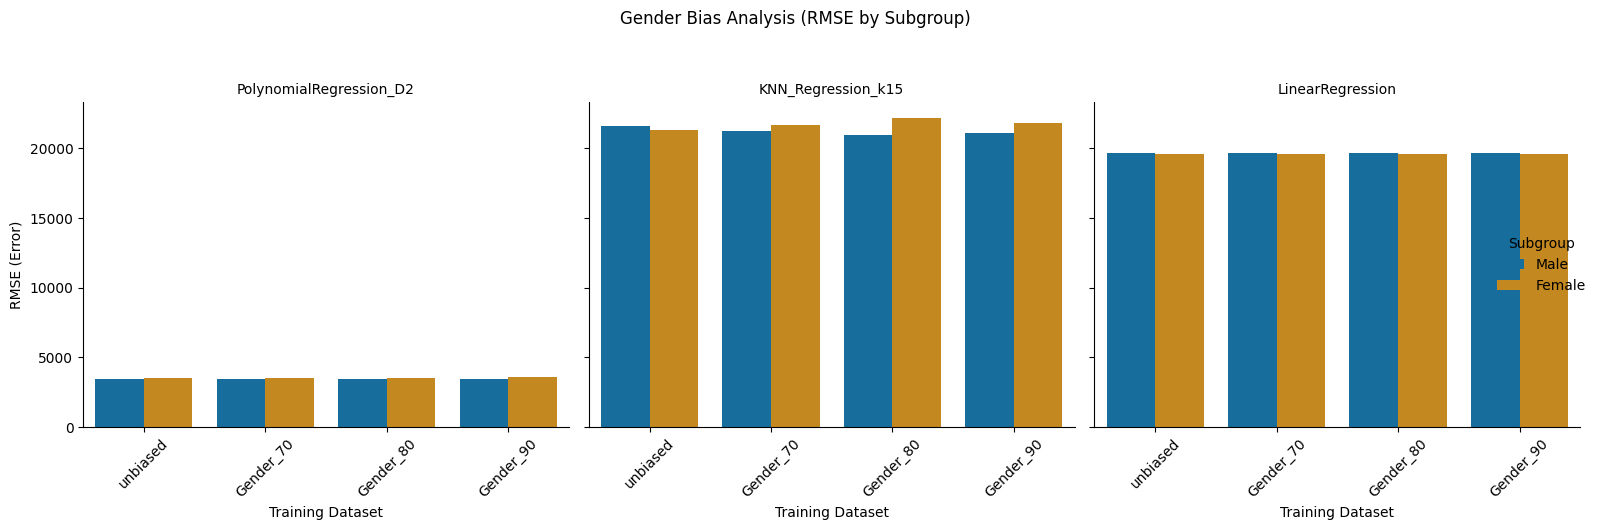

**Figure: Gender RMSE Disparity.**
The chart visualizes prediction error (RMSE) broken down by gender subgroups.
Columns represent different algorithms. The X-axis shows the training data used, ranging from unbiased to highly biased.
Key Insight: Diverging bars (gaps between groups) indicate potential bias. If the gap grows as you move right (towards 90% bias), the model is sensitive to representation.

--- Running Analysis: Age Group ---

Results:
                  Model    Train_Set Subgroup         RMSE  Category
PolynomialRegression_D2     unbiased    40-65  3427.719175 Age Group
PolynomialRegression_D2     unbiased     0-21  3681.570494 Age Group
PolynomialRegression_D2     unbiased      65+  3573.252172 Age Group
PolynomialRegression_D2     unbiased    21-40  3478.155518 Age Group
PolynomialRegression_D2 Age Group_70    40-65  3441.923717 Age Group
PolynomialRegression_D2 Age Group_70     0-21  3700.244716 Age Group
PolynomialRegression_D2 Age Group_70      65+  3602.881417 Age G

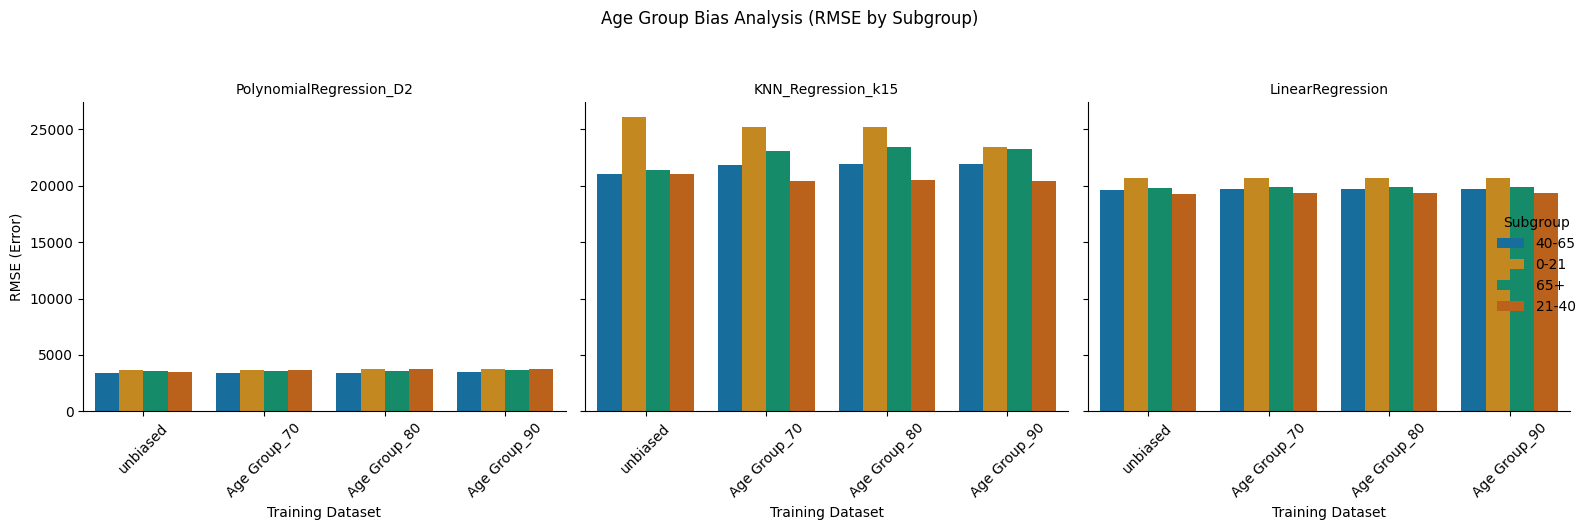

**Figure: Age Group RMSE Disparity.**
The chart visualizes prediction error (RMSE) broken down by age group subgroups.
Columns represent different algorithms. The X-axis shows the training data used, ranging from unbiased to highly biased.
Key Insight: Diverging bars (gaps between groups) indicate potential bias. If the gap grows as you move right (towards 90% bias), the model is sensitive to representation.


In [21]:
target_test_df = test_sets['unbiased']

configurations = [
    {
        "name": "Race",
        "col": "Race",
        "datasets": ['unbiased', 'Race_70', 'Race_80', 'Race_90']
    },
    {
        "name": "Gender",
        "col": "Gender",
        "datasets": ['unbiased', 'Gender_70', 'Gender_80', 'Gender_90']
    },
    {
        "name": "Age Group",
        "col": "Age Group",
        "datasets": ['unbiased', 'Age Group_70', 'Age Group_80', 'Age Group_90']
    }
]

for config in configurations:
    print(f"\n" + "="*40)
    print(f"--- Running Analysis: {config['name']} ---")
    print("="*40)

    bias_df = analyze_bias(
        fitted_models=fitted_models,
        test_df=target_test_df,
        target_col=target,
        group_col=config['col'],
        train_set_keys=config['datasets'],
        feature_cols=features
    )

    print("\nResults:")
    print(bias_df.head(len(bias_df)).to_string(index=False))

    visualize_bias(
        df=bias_df,
        category_name=config['name'],
        sort_order=config['datasets']
    )

#2. Age Group

In [22]:
url = 'https://raw.githubusercontent.com/aspenwang-vassar/CMPU-250-Project-Group-1/refs/heads/main/data/full_data.csv'
df = pd.read_csv(url)

#Make a copy of data
copy_data = df.copy()

df.head()



,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Hospital,Insurance Provider,Billing Amount,Admission Type,Discharge Date,Medication,Test Results,Race,Admission Length,Age Group
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Sons and Miller,Blue Cross,30859.992947,Urgent,2024-02-02,Paracetamol,Normal,White,2,21-40
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Kim Inc,Medicare,38471.107493,Emergency,2019-08-26,Ibuprofen,Inconclusive,Hispanic,6,40-65
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Cook PLC,Aetna,106615.993718,Emergency,2022-10-07,Aspirin,Normal,White,15,65+
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,"Hernandez Rogers and Vang,",Medicare,172540.102139,Elective,2020-12-18,Ibuprofen,Abnormal,White,30,21-40
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,White-White,Aetna,237377.467300,Urgent,2022-10-09,Penicillin,Abnormal,White,20,40-65


## Creating Age-Grouped Biased Datasets

In [23]:
#We want to skew the number of patients between 0-40 to be greater than the number of patients between 40-65+
prop = [0.3,0.2,0.1]  #The proportions we are controlling for(70-30,80-20,and 90-10)

#The Age Group we want to be the majority in our Data
group_majority = df[(df['Age Group'] == '0-21') | (df['Age Group'] == '21-40')]

#The Age Group we want to be the minority in our Data
group_minority = df[(df['Age Group'] == '40-65') | (df['Age Group'] == '65+')]
age_bias_datasets = []

#Creating the biased data
for proportion in prop:
    n = 0
    len_data = 10000  #We will shrink our data down into 1000 observations per dataset
    row_major = 0
    row_minor = 0
    index_major = []
    index_minor = []
    np.random.seed(42)

    while n < len_data:
        randy = np.random.rand()
        if(randy > proportion): #Ensures majority of our patients are from 0-40 age group
            index_major.append(row_major)
            row_major += 1
        else:
            index_minor.append(row_minor)
            row_minor += 1
        n += 1

    age_bias_datasets.append(pd.concat([group_majority.iloc[index_major,:],group_minority.iloc[index_minor,:]]))

age_bias7030,age_bias8020,age_bias9010 = age_bias_datasets[:3]

#Checking Proportions
for dataset in age_bias_datasets:
    counts = dataset['Age Group'].value_counts()
    num_obs = len(dataset['Age Group'])
    print(counts)
    print('Number of Observations',num_obs)

    #Checking for each group
    print('For Majority(70,80,90) Group', (counts['21-40'] + counts['0-21']) / num_obs)
    print('For Minority(30,20,10) Group', (counts['40-65'] + counts['65+']) / num_obs,'\n')


Age Group
21-40    5719
40-65    1662
65+      1391
0-21     1228
Name: count, dtype: int64
Number of Observations 10000
For Majority(70,80,90) Group 0.6947
For Minority(30,20,10) Group 0.3053 

Age Group
21-40    6560
0-21     1397
40-65    1104
65+       939
Name: count, dtype: int64
Number of Observations 10000
For Majority(70,80,90) Group 0.7957
For Minority(30,20,10) Group 0.2043 

Age Group
21-40    7405
0-21     1564
40-65     584
65+       447
Name: count, dtype: int64
Number of Observations 10000
For Majority(70,80,90) Group 0.8969
For Minority(30,20,10) Group 0.1031 



## Training Models using Linear,Polynomial,and KNN Regression

## Linear Regression

In [24]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#Dataset Dictionary to be used for our regression functions
datasets = {
    'Full Data': df,
    '70-30 Split': age_bias7030,
    '80-20 Split': age_bias8020,
    '90-10 Split':age_bias9010}

def linear_regression(datasets):
    #Features and Outcome of Interest
    features = ["Age","Admission Length","Gender","Blood Type","Medical Condition","Insurance Provider","Admission Type","Medication","Test Results","Race","Age Group"]
    outcome = "Billing Amount"

    #Continuous and Categorical features
    continuous = ["Age","Admission Length"]
    categorical = ['Gender','Blood Type','Medical Condition','Insurance Provider','Admission Type','Medication','Test Results','Race','Age Group']

    #Numerical Scaler to scale our continuous features
    numerical_scaler = StandardScaler()

    #Categorical transformer to convert our categorical variables into dummy variables
    categorical_scaler = OneHotEncoder(handle_unknown = 'ignore')

    #Process and prep our data using the transformers before beginning regression
    preprocess = ColumnTransformer(transformers = [("cont",numerical_scaler,continuous),("cat",categorical_scaler,categorical)])

    #Regression Model
    linear_model = Pipeline(steps = [('preprocessor',preprocess),('regressor',LinearRegression())])

    #Dictionaries to be outputed with each dataset's r2 and rmse values
    r2_dict = {}
    rmse_dict = {}

    for name,dataset in datasets.items():
        X = dataset[features]
        y = dataset[outcome]

        #1.Creating train and test sets
        X_train,X_test,y_train,y_test = sk.model_selection.train_test_split(X,y,test_size = 0.2,random_state = 42)

        #2.Fit model
        linear_model.fit(X_train,y_train)

        #3.Predict using model
        y_pred = linear_model.predict(X_test)

        #4.Calculate RMSE and R2
        r2 = r2_score(y_test,y_pred)
        rmse = np.sqrt(mean_squared_error(y_test,y_pred))
        print(f"{name}:",'R^2 =',r2,'RMSE' ,rmse,'\n')
        print(f"{name}:", 'Mean Predicted Billing Amount',np.mean(y_pred),'\n')
        r2_dict[name] = r2
        rmse_dict[name] = rmse

    return r2_dict,rmse_dict

lin_r2,lin_rmse = linear_regression(datasets)

Full Data: R^2 = 0.9040904219112319 RMSE 19619.269082483584 

Full Data: Mean Predicted Billing Amount 104328.28208951834 

70-30 Split: R^2 = 0.9014577789806746 RMSE 20113.00017687107 

70-30 Split: Mean Predicted Billing Amount 102005.03584627804 

80-20 Split: R^2 = 0.9020032063163531 RMSE 20569.43627617099 

80-20 Split: Mean Predicted Billing Amount 100044.96917414707 

90-10 Split: R^2 = 0.9034443613505395 RMSE 20088.64820423966 

90-10 Split: Mean Predicted Billing Amount 99420.97546498367 



## Polynomial Regression

In [25]:
def polynomial_regression(datasets):
    features = ["Age","Admission Length","Gender","Blood Type","Medical Condition","Insurance Provider","Admission Type","Medication","Test Results","Race","Age Group"]
    outcome = "Billing Amount"

    continuous = ["Age","Admission Length"]
    categorical = ['Gender','Blood Type','Medical Condition','Insurance Provider','Admission Type','Medication','Test Results','Race','Age Group']

    numerical_transformer = StandardScaler()
    categorical_transformer = OneHotEncoder(handle_unknown = 'ignore')

    preprocess = ColumnTransformer(transformers = [("cont",numerical_transformer,continuous),("cat",categorical_transformer,categorical)])

    #The polynomial model has an extra step of converting features to include polynomial coefficients after processing data and before regressing
    poly_model = Pipeline(steps=[("preprocessor", preprocessor),("poly", PolynomialFeatures(degree=2, include_bias=False)),("regressor", LinearRegression())])

    r2_dict = {}
    rmse_dict = {}

    for name,dataset in datasets.items():
        X = dataset[features]
        y = dataset[outcome]
        X_train,X_test,y_train,y_test = sk.model_selection.train_test_split(X,y,test_size = 0.2,random_state = 42)

        poly_model.fit(X_train,y_train)

        y_pred = poly_model.predict(X_test)
        r2 = r2_score(y_test,y_pred)
        rmse = np.sqrt(mean_squared_error(y_test,y_pred))

        print(f"{name}:",'R^2 =',r2,'RMSE' ,rmse,'\n')
        print(f"{name}:", 'Mean Predicted Billing Amount',np.mean(y_pred),'\n')
        r2_dict[name] = r2
        rmse_dict[name] = rmse

    return r2_dict,rmse_dict

poly_r2,poly_rmse = polynomial_regression(datasets)




Full Data: R^2 = 0.9969489261855847 RMSE 3499.275940241111 

Full Data: Mean Predicted Billing Amount 104061.4537147729 

70-30 Split: R^2 = 0.9967295073106277 RMSE 3664.1418275199367 

70-30 Split: Mean Predicted Billing Amount 101621.8820943298 

80-20 Split: R^2 = 0.9969239412188665 RMSE 3644.29706722416 

80-20 Split: Mean Predicted Billing Amount 100471.5528949098 

90-10 Split: R^2 = 0.9967953058716122 RMSE 3659.7817348214426 

90-10 Split: Mean Predicted Billing Amount 99765.96243058088 



## KNN Regression

In [26]:
from sklearn.neighbors import KNeighborsRegressor
def knn_regression(datasets):
    features = ["Age","Admission Length","Gender","Blood Type","Medical Condition","Insurance Provider","Admission Type","Medication","Test Results","Race","Age Group"]
    outcome = "Billing Amount"

    continuous = ["Age","Admission Length"]
    categorical = ['Gender','Blood Type','Medical Condition','Insurance Provider','Admission Type','Medication','Test Results','Race','Age Group']

    numerical_transformer = StandardScaler()
    categorical_transformer = OneHotEncoder(handle_unknown = 'ignore')

    preprocess = ColumnTransformer(transformers = [("cont",numerical_transformer,continuous),("cat",categorical_transformer,categorical)])

    #Used to create our KNN Model
    knn = KNeighborsRegressor(n_neighbors=15, weights="distance", p=2)

    knn_model = Pipeline(steps=[("preprocessor", preprocessor),("regressor", knn)])

    r2_dict = {}
    rmse_dict = {}

    for name,dataset in datasets.items():
        X = dataset[features]
        y = dataset[outcome]
        X_train,X_test,y_train,y_test = sk.model_selection.train_test_split(X,y,test_size = 0.2,random_state = 42)

        knn_model.fit(X_train,y_train)

        y_pred = knn_model.predict(X_test)
        r2 = r2_score(y_test,y_pred)
        rmse = np.sqrt(mean_squared_error(y_test,y_pred))

        print(f"{name}:",'R^2 =',r2,'RMSE' ,rmse,'\n')
        print(f"{name}:", 'Mean Predicted Billing Amount',np.mean(y_pred),'\n')
        r2_dict[name] = r2
        rmse_dict[name] = rmse

    return r2_dict,rmse_dict

knn_r2,knn_rmse = knn_regression(datasets)



Full Data: R^2 = 0.8933454267082177 RMSE 20689.09885209691 

Full Data: Mean Predicted Billing Amount 105723.44079092446 

70-30 Split: R^2 = 0.8390368984012215 RMSE 25705.665393955664 

70-30 Split: Mean Predicted Billing Amount 103858.74557765204 

80-20 Split: R^2 = 0.8275792419834029 RMSE 27284.20044527054 

80-20 Split: Mean Predicted Billing Amount 102361.34228502345 

90-10 Split: R^2 = 0.8364540719682302 RMSE 26144.58549557267 

90-10 Split: Mean Predicted Billing Amount 101675.62345986684 



## Table of Metrics

In [27]:
r_square = (list(lin_r2.values()) + list(poly_r2.values()) + list(knn_r2.values()))
r_square

rmse = (list(lin_rmse.values()) + list(poly_rmse.values()) + list(knn_rmse.values()))

r2_values = {
    'Linear Regression':[r_square[0],r_square[1],r_square[2],r_square[3]],
    'Polynomial Regression':[r_square[4],r_square[5],r_square[6],r_square[7]],
    'KNN Regression':[r_square[8],r_square[9],r_square[10],r_square[11]]
}
r2_values = pd.DataFrame(r2_values)
r2_values.index = ['Full Data','70%-30% Split','80%-20% Split','90%-10% Split']      #type:ignore

print('R2 Values','\n')
display(r2_values)

rmse_values = {
    'Linear Regression':[rmse[0],rmse[1],rmse[2],rmse[3]],
    'Polynomial Regression':[rmse[4],rmse[5],rmse[6],rmse[7]],
    'KNN Regression':[rmse[8],rmse[9],rmse[10],rmse[11]]
}
rmse_values = pd.DataFrame(rmse_values)
rmse_values.index = ['Full Data','70%-30% Split','80%-20% Split','90%-10% Split']      #type:ignore

print('RMSE Values','\n')
display(rmse_values)


R2 Values 



,Linear Regression,Polynomial Regression,KNN Regression
Full Data,0.904090,0.996949,0.893345
70%-30% Split,0.901458,0.996730,0.839037
80%-20% Split,0.902003,0.996924,0.827579
90%-10% Split,0.903444,0.996795,0.836454


RMSE Values 



,Linear Regression,Polynomial Regression,KNN Regression
Full Data,19619.269082,3499.275940,20689.098852
70%-30% Split,20113.000177,3664.141828,25705.665394
80%-20% Split,20569.436276,3644.297067,27284.200445
90%-10% Split,20088.648204,3659.781735,26144.585496


#3. Gender

## Creating Split Datasets
Here we are sampling patients from our main dataset in order to create biased splits to test our models on.

In [28]:
# Separate by gender
male_df = df[df["Gender"] == "Male"]
female_df = df[df["Gender"] == "Female"]

#splits (male, female)
splits = {
    "70_30": (0.7, 0.3),
    "80_20": (0.8, 0.2),
    "90_10": (0.9, 0.1)
}

for label, (male_ratio, female_ratio) in splits.items():
    total = len(df)
    male_target = int(total * male_ratio)
    female_target = int(total * female_ratio)

    # Sample data
    male_sample = male_df.sample(n=male_target, replace=len(male_df) < male_target, random_state=42)
    female_sample = female_df.sample(n=female_target, replace=len(female_df) < female_target, random_state=42)

    # Combine and shuffle
    new_df = pd.concat([male_sample, female_sample]).sample(frac=1, random_state=42).reset_index(drop=True)

    filename = f"clean_data_{label}.csv"
    new_df.to_csv(filename, index=False)

    #confirmation
    print("Gender distribution (%):")
    print(new_df["Gender"].value_counts(normalize=True) * 100)


Gender distribution (%):
Gender
Male      70.0
Female    30.0
Name: proportion, dtype: float64
Gender distribution (%):
Gender
Male      80.0
Female    20.0
Name: proportion, dtype: float64
Gender distribution (%):
Gender
Male      90.0
Female    10.0
Name: proportion, dtype: float64


## Linear Regression Pipeline

In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

url = 'https://raw.githubusercontent.com/aspenwang-vassar/CMPU-250-Project-Group-1/refs/heads/main/data/full_data.csv'
full_data = pd.read_csv(url)
df = full_data.copy()


df["Admission Length"] = (
    df["Admission Length"].astype(str).str.replace(" days", "", regex=False).astype(float)
)

target = "Billing Amount"
features = [
    "Age",
    "Admission Length",
    "Gender",
    "Blood Type",
    "Medical Condition",
    "Insurance Provider",
    "Admission Type",
    "Medication",
    "Test Results",
    "Race",
    "Age Group"
]

X = df[features]
y = df[target]


numeric_features = ["Age", "Admission Length"]


categorical_features = [
    "Gender",
    "Blood Type",
    "Medical Condition",
    "Insurance Provider",
    "Admission Type",
    "Medication",
    "Test Results",
    "Race",
    "Age Group",
]

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

poly_model = Pipeline(steps=[("preprocessor", preprocessor), ('poly', PolynomialFeatures(degree = 2, include_bias = False)),("regressor", LinearRegression())])

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"R²: {r2:.4f} | RMSE: {rmse:.2f}")

R²: 0.9041 | RMSE: 19619.27


## Testing Linear Regression on Splits
Tests a linear regression model on 70/30, 80/20, and 90/10 gender distribution splits.

In [30]:
datasplits = {
'Full data':df,
'70_30': pd.read_csv('clean_data_70_30.csv'),
'80_20': pd.read_csv('clean_data_80_20.csv'),
'90_10': pd.read_csv('clean_data_90_10.csv')
}

gender_lin_r2,gender_lin_rmse = linear_regression(datasplits)

def clean_admission_length(df):
    df = df.copy()
    df["Admission Length"] = (
        df["Admission Length"].astype(str).str.replace(" days", "", regex=False).astype(float)
    )
    return df

for ratio in ["70_30", "80_20", "90_10"]:
    altered_df = pd.read_csv(f"clean_data_{ratio}.csv")
    altered_df = clean_admission_length(altered_df)

    X_alt = altered_df[[
        "Age","Admission Length","Gender","Blood Type","Medical Condition",
        "Insurance Provider","Admission Type","Medication","Test Results",
        "Race","Age Group"
    ]]

    y_alt_pred = model.predict(X_alt)
    altered_df["Predicted Billing Amount"] = y_alt_pred
    altered_df.to_csv(f"predicted_billing_{ratio}.csv", index=False)

    print(f"\nResults for {ratio} dataset:")
    print(f"Mean predicted billing: {y_alt_pred.mean():.2f}")
    print(f"Std. deviation: {y_alt_pred.std():.2f}",'\n')


Full data: R^2 = 0.9040904219112319 RMSE 19619.269082483584 

Full data: Mean Predicted Billing Amount 104328.28208951834 

70_30: R^2 = 0.9020034860602157 RMSE 19922.87775905117 

70_30: Mean Predicted Billing Amount 104566.97482600441 

80_20: R^2 = 0.9031220539908926 RMSE 19672.835404120466 

80_20: Mean Predicted Billing Amount 103954.86537737733 

90_10: R^2 = 0.9019870926491002 RMSE 19949.402909204822 

90_10: Mean Predicted Billing Amount 104308.69658859936 


Results for 70_30 dataset:
Mean predicted billing: 104880.39
Std. deviation: 60859.19 


Results for 80_20 dataset:
Mean predicted billing: 104915.24
Std. deviation: 60806.64 


Results for 90_10 dataset:
Mean predicted billing: 104894.97
Std. deviation: 60812.63 



## Polynomial Regression + Testing
Tests a polynomial regression model on 70/30, 80/20, and 90/10 gender distribution splits.

In [31]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

datasplits = {
'Full_data': df,
'70_30': pd.read_csv('clean_data_70_30.csv'),
'80_20': pd.read_csv('clean_data_80_20.csv'),
'90_10': pd.read_csv('clean_data_90_10.csv')
}

gender_poly_r2,gender_poly_rmse = polynomial_regression(datasplits)


Full_data: R^2 = 0.99694892680138 RMSE 3499.275587113386 

Full_data: Mean Predicted Billing Amount 104061.45376707107 

70_30: R^2 = 0.9970151105869679 RMSE 3477.0495504328833 

70_30: Mean Predicted Billing Amount 104520.68857561634 

80_20: R^2 = 0.9971014752871131 RMSE 3402.851531257636 

80_20: Mean Predicted Billing Amount 103882.96832145154 

90_10: R^2 = 0.9971240723476383 RMSE 3417.2538703530654 

90_10: Mean Predicted Billing Amount 104412.225864583 



## KNN Regression  + Testing
Tests a K-Nearest Neighbors regression model on 70/30, 80/20, and 90/10 gender distribution splits.

In [32]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error

datasplits = {
'Full_data': df,
'70_30': pd.read_csv('clean_data_70_30.csv'),
'80_20': pd.read_csv('clean_data_80_20.csv'),
'90_10': pd.read_csv('clean_data_90_10.csv')
}

gender_knn_r2,gender_knn_rmse = knn_regression(datasplits);





Full_data: R^2 = 0.8933454267082177 RMSE 20689.09885209691 

Full_data: Mean Predicted Billing Amount 105723.44079092446 

70_30: R^2 = 0.9342410377967535 RMSE 16320.153237783756 

70_30: Mean Predicted Billing Amount 105221.93098628847 

80_20: R^2 = 0.9444794634075466 RMSE 14892.970339944033 

80_20: Mean Predicted Billing Amount 104574.65400820399 

90_10: R^2 = 0.9558484856710433 RMSE 13389.398508477245 

90_10: Mean Predicted Billing Amount 104765.13562520602 



## Table of Metrics

In [33]:
r_square_gen = (list(gender_lin_r2.values()) + list(gender_poly_r2.values()) + list(gender_knn_r2.values()))
r_square_gen

r2_values_gen = {
    'Algorithm':['Full Data','70%-30% Split','80%-20% Split','90%-10% Split'],
    'Linear Regression':[r_square_gen[0],r_square_gen[1],r_square_gen[2],r_square_gen[3]],
    'Polynomial Regression':[r_square_gen[4],r_square_gen[5],r_square_gen[6],r_square_gen[7]],
    'KNN Regression':[r_square_gen[8],r_square_gen[9],r_square_gen[10],r_square_gen[11]]
}
r2_values_gen = pd.DataFrame(r2_values_gen)

print('R2 Values','\n')
display(r2_values_gen)

rmse_gen = (list(gender_lin_rmse.values()) + list(gender_poly_rmse.values()) + list(gender_knn_rmse.values()))

rmse_values_gen = {
    'Algorithm':['Full Data','70%-30% Split','80%-20% Split','90%-10% Split'],
    'Linear Regression':[rmse,rmse_gen[1],rmse_gen[2],rmse_gen[3]],
    'Polynomial Regression':[rmse_gen[4],rmse_gen[5],rmse_gen[6],rmse_gen[7]],
    'KNN Regression':[rmse_gen[8],rmse_gen[9],rmse_gen[10],rmse_gen[11]]
}
rmse_values_gen = pd.DataFrame(rmse_values_gen)


print('RMSE Values','\n')
display(rmse_values_gen)


R2 Values 



,Algorithm,Linear Regression,Polynomial Regression,KNN Regression
0,Full Data,0.904090,0.996949,0.893345
1,70%-30% Split,0.902003,0.997015,0.934241
2,80%-20% Split,0.903122,0.997101,0.944479
3,90%-10% Split,0.901987,0.997124,0.955848


RMSE Values 



,Algorithm,Linear Regression,Polynomial Regression,KNN Regression
0,Full Data,19619.269082,3499.275587,20689.098852
1,70%-30% Split,19922.877759,3477.049550,16320.153238
2,80%-20% Split,19672.835404,3402.851531,14892.970340
3,90%-10% Split,19949.402909,3417.253870,13389.398508


# Historical Bias Analysis
We want to examine the impact of historical bias on mean billing amount predicted by a polynomial regression algorithm

In [34]:
print('Polynomial Regression')
polynomial_regression({'Full_data':df})
polynomial_regression({'Historical Bias data':hist_df})

print('KNN Regression')
knn_regression({'Full_data':df})
knn_regression({'Historical Bias data':hist_df})

print('Linear Regression')
linear_regression({'Full_data':df})
linear_regression({'Historical Bias data':hist_df})

Polynomial Regression
Full_data: R^2 = 0.99694892680138 RMSE 3499.275587113386 

Full_data: Mean Predicted Billing Amount 104061.45376707107 

Historical Bias data: R^2 = 0.9982770095181958 RMSE 2621.99873745442 

Historical Bias data: Mean Predicted Billing Amount 99758.8152020742 

KNN Regression
Full_data: R^2 = 0.8933454267082177 RMSE 20689.09885209691 

Full_data: Mean Predicted Billing Amount 105723.44079092446 

Historical Bias data: R^2 = 0.895571061545939 RMSE 20412.74784002384 

Historical Bias data: Mean Predicted Billing Amount 101410.11649100888 

Linear Regression
Full_data: R^2 = 0.9040904219112319 RMSE 19619.269082483584 

Full_data: Mean Predicted Billing Amount 104328.28208951834 

Historical Bias data: R^2 = 0.9052385709096749 RMSE 19444.95040976086 

Historical Bias data: Mean Predicted Billing Amount 100025.6227224887 



({'Historical Bias data': 0.9052385709096749},
 {'Historical Bias data': np.float64(19444.95040976086)})